# Project B - Step 6: The anchor panel and the confound ratio comparison

**Status:** Step 6 of 6. This is where a lone number becomes a **finding**. We run the *same* two-knob audit across three reliability estimators and let the confound ratio discriminate between them.

## The panel
| Method | Reliability comes from | Prediction |
|---|---|---|
| **TMC** (evidential) | each view scored **in isolation** | immune to misalignment (`S_a`=0) |
| **Deep ensembles** | each view's ensemble disagreement, **in isolation** | immune (`S_a`=0) |
| **Clean-room coupled baseline** | **cross-view agreement** | **fooled** (`S_a` high) |

## What we expect
The confound ratio should track **one axis: isolated vs coupled**, not the specific UQ method. If so, the metric is doing real work.

In [1]:
import os, urllib.request, pickle
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

SEED=0; torch.manual_seed(SEED); np.random.seed(SEED); K=10
BASE=("https://raw.githubusercontent.com/mvlearn/mvlearn/main/"
      "mvlearn/datasets/UCImultifeature")
def load_view(filename, cache_dir="mfeat_data"):
    os.makedirs(cache_dir, exist_ok=True); path=os.path.join(cache_dir,filename)
    if not os.path.exists(path): urllib.request.urlretrieve(f"{BASE}/{filename}", path)
    arr=np.genfromtxt(path,delimiter=",")[1:]; return arr[:,:-1], arr[:,-1].astype(int)

Xa,y=load_view("mfeat-fou.csv"); Xb,_=load_view("mfeat-fac.csv"); raw=[Xa,Xb]
idx=np.arange(len(y))
train_idx,test_idx=train_test_split(idx,test_size=0.3,stratify=y,random_state=SEED)
scalers=[StandardScaler().fit(X[train_idx]) for X in raw]
Xs=[torch.tensor(s.transform(X),dtype=torch.float32) for s,X in zip(scalers,raw)]
y_t=torch.tensor(y)
AUDIT_VIEW=1   # audit view B (profile correlations)
print("data ready")

data ready


## Anchor 1 - TMC (load from Step 3)

In [2]:
class EvidentialNet(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,200),nn.ReLU(),nn.Linear(200,200),nn.ReLU(),nn.Linear(200,K))
    def forward(self,x): return F.softplus(self.net(x))

if os.path.exists("tmc_nets.pt"):
    sd=torch.load("tmc_nets.pt"); dims=[X.shape[1] for X in raw]
    tmc=[EvidentialNet(d) for d in dims]
    for n,s in zip(tmc,sd): n.load_state_dict(s); n.eval()
    print("loaded TMC from Step 3")
else:
    raise FileNotFoundError("Run Step 3 first to produce tmc_nets.pt")

def tmc_signal(X_view, idx):
    """TMC reliability (uncertainty u) for the audited view. Isolated: sees only its own input."""
    Xn=torch.tensor(scalers[AUDIT_VIEW].transform(X_view[idx]),dtype=torch.float32)
    with torch.no_grad(): return (K/(tmc[AUDIT_VIEW](Xn)+1).sum(1)).numpy()

loaded TMC from Step 3


## Anchor 2 - Deep ensembles
`M` plain classifiers per view, trained from different seeds. Reliability signal = predictive entropy of the mean softmax. Isolated: each view's ensemble sees only its own input.

In [ ]:
class MLP(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,200),nn.ReLU(),nn.Linear(200,200),nn.ReLU(),nn.Linear(200,K))
    def forward(self,x): return self.net(x)

M=5
ens=[[MLP(raw[v].shape[1]) for _ in range(M)] for v in (0,1)]
for v in (0,1):
    for m,net in enumerate(ens[v]):
        torch.manual_seed(100*v+m); net.net[0].reset_parameters()
        opt=torch.optim.Adam(net.parameters(),lr=1e-3,weight_decay=1e-5)
        for ep in range(150):
            net.train(); loss=F.cross_entropy(net(Xs[v][train_idx]), y_t[train_idx])
            opt.zero_grad(); loss.backward(); opt.step()
        net.eval()

def view_probs(v, X_view, idx):
    Xn=torch.tensor(scalers[v].transform(X_view[idx]),dtype=torch.float32)
    with torch.no_grad():
        return torch.stack([F.softmax(net(Xn),1) for net in ens[v]]).mean(0).numpy()

def entropy(p): return -(p*np.log(p+1e-12)).sum(1)

def ensemble_signal(X_view, idx):
    return entropy(view_probs(AUDIT_VIEW, X_view, idx))
print("ensembles trained")

ensembles trained


## Anchor 3 - Clean-room coupled baseline (the ARAF idea)
A view is deemed unreliable when it **disagrees with its partner**. We use the Jensen-Shannon divergence between the audited view's prediction and its partner's (clean) prediction. This is **coupled**: the signal depends on the other modality. Intuitive, reasonable, and exactly the kind of estimator the hypothesis targets.

In [ ]:
def js(p,q):
    m=0.5*(p+q)
    return 0.5*(p*np.log((p+1e-12)/(m+1e-12))).sum(1)+0.5*(q*np.log((q+1e-12)/(m+1e-12))).sum(1)

pA_clean = view_probs(0, raw[0], test_idx)

def coupled_signal(X_view, idx):
    pB = view_probs(AUDIT_VIEW, X_view, idx)
    return js(pB, pA_clean)
print("coupled baseline ready")

coupled baseline ready


## The shared audit harness
One function, method-agnostic. Each method just supplies a `signal_fn(X_view, idx)`. This *is* the protocol - the contribution is that any reliability estimator plugs into the same two knobs.

In [5]:
NOISE_LEVELS=[0.0,0.25,0.5,1.0,1.5,2.0]; FRACS=[0.0,0.25,0.5,0.75,1.0]
sev1=np.array(NOISE_LEVELS)/max(NOISE_LEVELS); sev2=np.array(FRACS)
rng=np.random.default_rng(SEED)

def misalign(rows, frac):
    rows=rows.copy(); n=int(round(frac*len(rows)))
    if n>1:
        s=rng.choice(len(rows),n,replace=False); rows[s]=rows[s][rng.permutation(n)]
    return rows

def run_audit(signal_fn, draws=3):
    # Knob 1: genuine noise on the audited view (averaged over draws)
    q=[]
    for lvl in NOISE_LEVELS:
        vals=[]
        for _ in range(draws):
            Xn=raw[AUDIT_VIEW]+rng.normal(0,1,raw[AUDIT_VIEW].shape)*raw[AUDIT_VIEW].std(0)*lvl
            vals.append(signal_fn(Xn, test_idx).mean())
        q.append(np.mean(vals))
    # Knob 2: alignment-only (permute audited-view rows)
    a=[signal_fn(raw[AUDIT_VIEW], misalign(test_idx, f)).mean() for f in FRACS]
    q,a=np.array(q),np.array(a)
    S_q=np.polyfit(sev1,q,1)[0]; S_a=np.polyfit(sev2,a,1)[0]
    ratio=abs(S_a)/abs(S_q) if S_q!=0 else float("inf")
    return dict(q=q, a=a, S_q=S_q, S_a=S_a, ratio=ratio)

methods={"TMC (isolated)":tmc_signal,
         "Deep ensembles (isolated)":ensemble_signal,
         "Coupled clean-room (ARAF idea)":coupled_signal}
results={name:run_audit(fn) for name,fn in methods.items()}

summary=pd.DataFrame({n:{"S_q":round(r["S_q"],4),"S_a":round(r["S_a"],4),
                         "confound ratio":round(r["ratio"],3)} for n,r in results.items()}).T
summary

,S_q,S_a,confound ratio
TMC (isolated),0.0304,0.0000,0.000
Deep ensembles (isolated),0.1744,0.0000,0.000
Coupled clean-room (ARAF idea),0.0591,0.5039,8.519


## The picture
Left: each method's response to both knobs (genuine = solid, misalignment = dashed). Right: the confound ratios side by side.

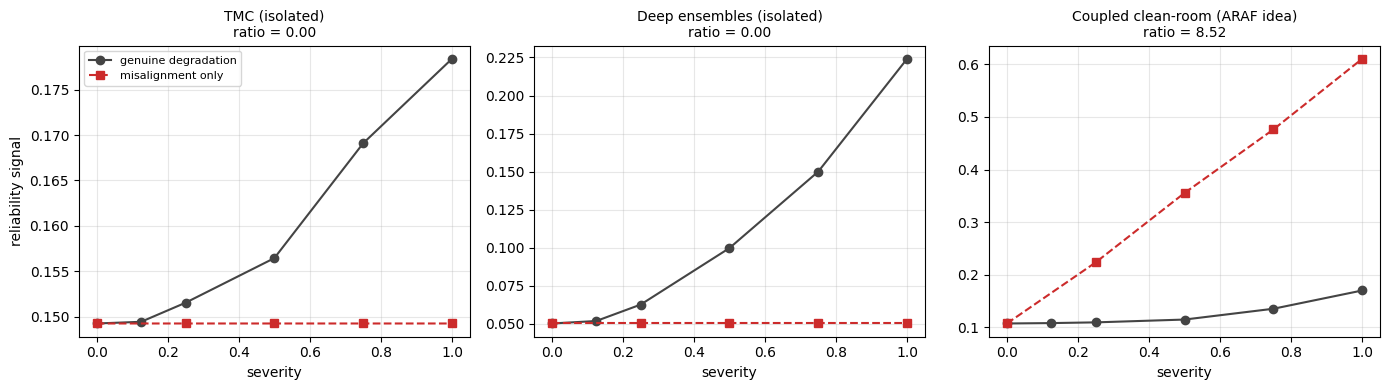

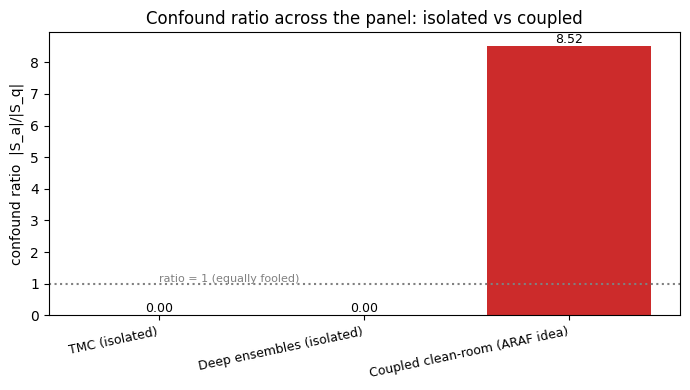

In [6]:
fig,axes=plt.subplots(1,len(methods),figsize=(14,4),sharey=False)
for ax,(name,r) in zip(axes,results.items()):
    ax.plot(sev1,r["q"],"o-",color="#444",label="genuine degradation")
    ax.plot(sev2,r["a"],"s--",color="#cc2b2b",label="misalignment only")
    ax.set_title(f"{name}\nratio = {r['ratio']:.2f}",fontsize=10)
    ax.set_xlabel("severity"); ax.grid(alpha=0.3)
axes[0].set_ylabel("reliability signal"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(7,4))
names=list(results); ratios=[results[n]["ratio"] for n in names]
bars=ax.bar(range(len(names)),ratios,color=["#3a7","#3a7","#cc2b2b"])
ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=12,ha="right",fontsize=9)
ax.set_ylabel("confound ratio  |S_a|/|S_q|")
ax.axhline(1.0,ls=":",color="gray"); ax.text(0,1.05,"ratio = 1 (equally fooled)",fontsize=8,color="gray")
for b,v in zip(bars,ratios): ax.text(b.get_x()+b.get_width()/2,v+0.1,f"{v:.2f}",ha="center",fontsize=9)
ax.set_title("Confound ratio across the panel: isolated vs coupled"); plt.tight_layout(); plt.show()

## What this shows - the finding

**The confound ratio tracks one axis: isolated vs coupled.**

- **TMC and deep ensembles (isolated): ratio ~ 0.** Misaligning a view cannot change a reliability signal that only looks at that view's own input. The Step 2 sanity check already showed this same misalignment *destroys* fused accuracy, so the knob is potent - these estimators simply cannot see it. Notably, deep ensembles are also *responsive* to genuine degradation (`S_q`~0.19), so they are honest **and** useful here.
- **Coupled clean-room baseline: ratio ~ 9.** It is roughly **nine times more sensitive to misalignment than to genuine degradation**. A pristine modality that is merely mis-paired gets flagged as unreliable. This is *misalignment masquerading as unreliability*, demonstrated and quantified on real data.

**Why it matters:** agreement-based reliability is intuitive and common ("trust the views that agree"). The audit shows that intuition has a specific, measurable failure mode, and the confound ratio is the instrument that detects it. The metric earns its keep by separating estimators that *cannot* be fooled from one that badly is.

### Honest caveats
- One dataset (Handwritten), one audited view, one seed. KITTI and Project C are where this gets stress-tested on real sensors.
- For isolated methods the ratio is ~0 because `S_a` is **structurally** 0; report absolute `S_q` and `S_a`, never the ratio alone.
- The coupled baseline is one reasonable design, not "the" coupled estimator. The claim is about a *class* of agreement-based estimators.
- Severity is the simple [0,1] normalisation; the accuracy-matched version is the planned refinement.

## Roadmap - all six steps done
1. Pick dataset - done   2. Sanity-check - done   3. TMC up - done
4. Reliability signal - done   5. Two-knob test - done   6. **Panel + confound ratio - done**

**The pipeline is now a finding.** Next horizons:
- **KITTI validation** (camera + LiDAR, calibration-perturbation as the misalignment knob) - the bridge to Project C.
- **The accuracy-matched severity refinement** and more seeds/views for error bars.
- **Write-up framing**, still gated on the literature sweep (forward-citation check on TMC; TMUR and the conflictive-multi-view line). The measurement is solid; positioning "confound ratio" as the contribution is the remaining gate.